In [3]:
# 모델 구조
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.c1 = nn.Conv2d(in_c, out_c, 3, padding=0, bias=True)
        self.c1 = nn.Conv2d(out_c, out_c, 3, padding=0, bias=True)
        self.r = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.c1(x)
        out = self.r(self.c2(x))
        return out

class Down(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block = DoubleConv(in_c, out_c)
    
    def forward(self, x):
        x = self.pool(x)
        out = self.block(x)
        return out
    
class Up(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_c, in_c//2, 2, stride=2)
        self.block = DoubleConv(in_c, out_c)

    def forward(self, x, skip):
        x = self.up(x)
        th, tw = x.shape[-2:] # 팽창된 이미지의 크기를 알아야함
        hs, ws = skip.shape[-2:] # 원본이 잘린 횟수가 적으므로 원본의 크기에서 길이를 빼야됨(아래 코드)
        dh, dw = (hs-th) // 2, (ws-tw) // 2
        skip_c = skip[..., dh:dh+th, dw:dw+tw] 
        x = torch.cat([skip_c, x], dim=1) # 여기서 합치는 것이 아니라 '붙이는 것'임(전혀 다른 표현)
        out = self.block(x)
        return out

# Unet은 논문을 기반으로 구현할 것이기 때문에 이렇게 구현하는 것이며 사람마다 구현이 다를 수 있음
class UNet(nn.Module): # 유넷의 핵심은 지름길(skip connection)이므로 다른 건 바뀌어도 이건 안 바뀜
    def __init__(self, in_c=3, n_classes=1, base=64): # base는 초기 채널값임
        super().__init__()
        self.inc = DoubleConv(in_c, base) # 파스칼 데이터를 쓰므로 기본값 3으로 설정(3채널 이미지)
        self.down1 = Down(base, base*2)
        self.down2 = Down(base*2, base*4)
        self.down3 = Down(base*4, base*8)
        self.down4 = Down(base*8, base*16)
        self.up1 = Up(base*16, base*8)
        self.up2 = Up(base*8, base*4)
        self.up3 = Up(base*4, base*2)
        self.up4 = Up(base*2, base)
        self.outc = nn.Conv2d(base, n_classes, 1)

    def forward(self, x):
        # 인코딩 층
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        # 디코더 층
        x = self.up1(x5, x4) # Up클래스는 2개를 입력 받음, 지름길 데이터는 이전 작업 데이터를 받으므로 이와 같은 코드로 작성됨
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        # 출력 층
        out = self.outc(x)
        return out

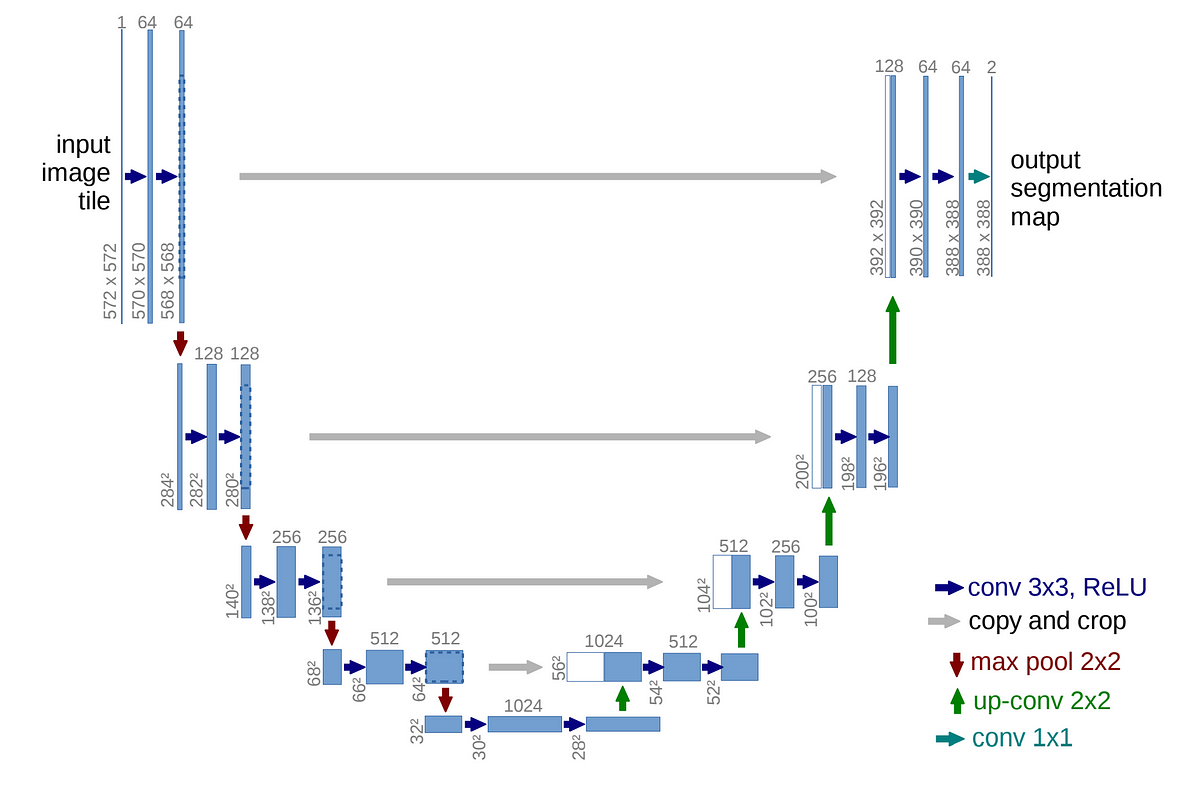
https://miro.medium.com/max/1200/1*qNdglJ1ORP3Gq77MmBLhHQ.png

In [10]:
import os, time
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

# 상수 정의
NUM_WORKERS = 4
DATA_ROOT = './data/VOCdevkit'
SPLIT = 'VOC2012'
BATCH_SIZE = 32
EPOCHS = 5
LR = 5e-3 # 초반엔 작게 주는 게 좋음
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

IMG_SIZE = 512
N_CLASSES = 21
IGNORE_INDEX = 255

OUT_DIR = 'runs/fcn_scratch'
BEST_PATH = os.path.join(OUT_DIR, 'best_m.pth')
os.makedirs(OUT_DIR, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
# 데이터 수집(데이터 로드)
def make_transform(train):
    def _tfm(img, mask):
        img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1) < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        return img, mask
    return _tfm

class VOCDatasetTrain(Dataset):
    def __init__(self, root, split, image_set, transforms=None):
        base = Path(root)/split
        self.img_dir = base/'JPEGImages'
        self.mask_dir = base/'SegmentationClass'
        with open(base/'ImageSets'/'Segmentation'/f'{image_set}.txt') as f:
            self.ids = [x for x in f if x.strip()]
        self.tfm = transforms
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, index):
        id_ = self.ids[index]
        img = Image.open(self.img_dir/f'{id_.strip()}.jpg').convert('RGB')
        mask = Image.open(self.mask_dir/f'{id_.strip()}.png')
        if self.tfm:
            img, mask = self.tfm(img, mask)
        return img, mask

class VOCDatasetVal(VOCDatasetTrain):
    def __getitem__(self, idx):
        id_ = self.ids[idx]
        img = Image.open(self.img_dir/f'{id_.strip()}.jpg').convert('RGB')
        mask = Image.open(self.mask_dir/f'{id_.strip()}.png')
        if self.tfm:
            img, mask = self.tfm(img, mask)
        return img, mask, id_

def get_loader():
    tr_ds = VOCDatasetTrain(DATA_ROOT, SPLIT, 'train', transforms=make_transform(train=True))
    val_ds = VOCDatasetVal(DATA_ROOT, SPLIT, 'val', transforms=make_transform(train=False))
    # tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)    
    # val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # pin메모리는 GPU를 사용하는 것임
    val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return tr_ds, val_ds, tr_ds_loader, val_ds_loader

In [12]:
# 데이터 준비
tr_ds, val_ds, tr_ds_loader, val_ds_loader = get_loader()

In [13]:
# 모델 학습
m = UNet(3, N_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt = torch.optim.SGD(m.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
# torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available()) 아래가 권장 코드임
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

In [ ]:
def train(model, loader, criterion, optimizer, scaler, device, epoch):
    model.train()
    run = 0.0
    t0 = time.time() # 에폭당 학습시간
    for x, y in tqdm(loader): # 스텝당 학습시간
        imgs, masks = x.to(device), y.to(device)
        opt.zero_grad(set_to_none=True) # 메모리 낭비를 효율적으로
        with torch.amp.autocast(enabled=torch.cuda.is_available()): # 연산의 효율을 높이기
            out = model(imgs)
            
def evaluate():
    pass